# Beamforming (pytorch)

In this notebook, we locate the source of a synthetic wavefield recorded on an array of sensors using beamforming. The notebook follows three steps:

1. Geometry: define the geometry of sensors, source, and gridpoints to test
2. Recordings (synthetic): compute synthetic seismograms recorded on each sensor
3. Beamforming: compute cross-correlation beamformer output within a frequency band

For more background information, see the README.

**Memory limitation**

The memory-limit you will likely encounter first is the size of $S$, which has the shape `(n_gridpoints, n_sensors, n_sensors, n_frequencies)`. For example, $S$ would have to be **6.5 TiB**, far exceeding most systems, with these parameters:
* `n_sensors = 1000`
* `grid_limit = 100`
* `grid_spacing = 2`
* `window_length = 100`
* `sampling_rate = 10`
* `fmin, fmax = 0.1, 1.0`

See `beamforming_dask.ipynb` for the adapted `dask`-version of this notebook, which is able to compute the beampowers for the parameters above.

**On `pytorch` vs `numpy`**

Note that the `pytorch` functions in this notebook can be replaced mostly one-to-one with `numpy` equivalents. However, from my experience on my machine, `numpy` is significantly slower (about 50%), particularly when using `einsum()`.

## 1. Geometry

Text(0.5, 1.0, 'geometry of sensors, source, and grid')

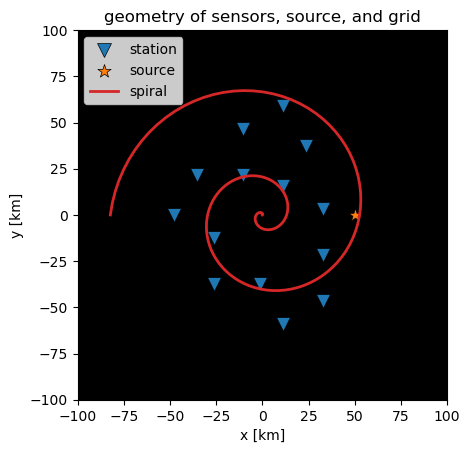

In [6]:
from itertools import product

import pylab as plt
import torch

# torch.set_grad_enabled(False)
torch.manual_seed(42)

# geometry of the problem
n_sensors = 150
# uniform random distribution in [-25, 25]
stations = torch.rand((n_sensors, 2)) * 50
stations -= 25

def tile(p):
    import numpy as np
    a = p
    b = 1 - p
    c = np.cos(np.pi / 3)
    s = np.sin(np.pi / 3)

    x = [c * b, b, 0, s * a, c * b, -c * b, s * a, 0, 0, -s * a, -c * b, -b, 0, -s * a]
    y = [s * b, 0, a, c * a, -s * b, -s * b, -c * a, -a, -a, -c * a, s * b, 0, a, c * a]
    x = np.cumsum(x)
    y = np.cumsum(y)
    return torch.tensor([x, y]).T

stations = tile(0.5)
stations *= 50
stations[:, 0] -= torch.mean(stations, 0)[0]

# stations in a circle
def circle(n_points, radius=1, noise=0.0):
    t = torch.linspace(0, 2 * torch.pi, n_points)
    x = radius * torch.cos(t)
    y = radius * torch.sin(t)
    circle = torch.stack([x, y], 1)
    return circle + torch.randn_like(circle) * noise
# stations = circle(len(tile(0)), radius=50, noise=0)

# spiral function
def spiral(n_points, n_turns=1, noise=0.0):
    t = torch.linspace(0, n_turns * 2 * torch.pi, n_points)
    r = t ** 2
    x = r * torch.cos(t)
    y = r * torch.sin(t)
    spiral = torch.stack([x, y], 1)
    return spiral + torch.randn_like(spiral) * noise
sources = spiral(200, n_turns=2.5, noise=0)
sources /= 3

# sources in a grid
grid_limit = 75
grid_spacing = 5
grid_coords = torch.arange(-grid_limit, grid_limit, grid_spacing)
# sources = torch.tensor(list(product(grid_coords, repeat=2)))
# sources = sources + torch.randn_like(sources) * 0.5



source = torch.tensor([50, 0])

# generate grid points
grid_limit = 150
grid_spacing = 1
grid_coords = torch.arange(-grid_limit, grid_limit, grid_spacing)
gridpoints = torch.tensor(list(product(grid_coords, repeat=2)))

# generate empty grid cells for visulation
xx, yy = torch.meshgrid(grid_coords, grid_coords, indexing="xy")
empty_cells = torch.zeros_like(xx) * torch.nan

# plotting
fig, ax = plt.subplots(1)
ax.pcolormesh(xx, yy, empty_cells, ec="k", lw=0.01)
ax.scatter(*stations.T, marker="v", s=100, label="station", ec='k', lw=0.5)
ax.scatter(*source, marker="*", s=100, label="source", ec='k', lw=0.5)
ax.plot(sources[:, 0], sources[:, 1], label="spiral", lw=2, c="tab:red")
ax.set_xlim(-100, 100)
ax.set_ylim(-100, 100)
ax.set_aspect("equal")
ax.legend(loc=2)
ax.set_xlabel("x [km]")
ax.set_ylabel("y [km]")
ax.set_title("geometry of sensors, source, and grid")

## 2. Recordings (synthetic)

In a field data application, replace `waveform_spectra` by the spectra of your recordings.

tensor(0.3642, dtype=torch.float64) tensor(43.7402, dtype=torch.float64)


Text(0.5, 1.0, '(synthetic) recordings on sensors')

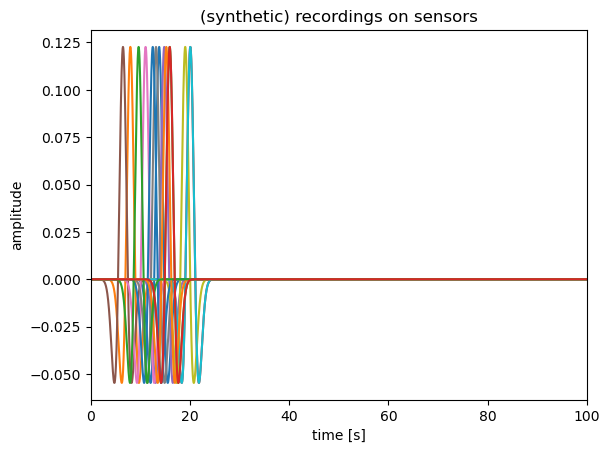

In [7]:
from scipy.signal import ricker

# define time
window_length = 100
sampling_rate = 50
times = torch.arange(0, window_length, 1 / sampling_rate)

# compute frequencies
freqs = torch.fft.fftfreq(len(times), 1 / sampling_rate)
omega = 2 * torch.pi * freqs

# define medium
# acoustic homogeneous half-space
medium_velocity = 3

# compute travel times
# print(stations.shape, sources.shape)
# print(stations[None, :, :].shape, sources[:, None, :].shape)
distances = torch.linalg.norm(stations[None, :, :] - sources[:, None, :], axis=-1)
traveltimes = distances / medium_velocity
print(traveltimes.min(), traveltimes.max())

# define source wavelet
wavelet = torch.fft.fft(torch.fft.fftshift(torch.from_numpy(ricker(len(times), sampling_rate))))

# print(omega.shape, traveltimes.shape)
# print(omega[:, None, None].shape, traveltimes[None, :, :].shape)
# compute waveforms for all stations for given source
# Green's functions are exp(-iωt)
# waveforms are only computed for plotting purposes.
# In a usual field data application, waveforms already exist
# and waveform_spectra need to be computed.
waveform_spectra = wavelet[None, None, :] * torch.exp(-1j * omega[None, None, :] * traveltimes[:, :, None])
waveforms = torch.fft.ifft(waveform_spectra, axis=-1).real

# add noise
# waveforms += torch.randn_like(waveforms) * torch.max(waveforms) * 0.2
# waveform_spectra = torch.fft.fft(waveforms, axis=-1)

# plotting
fig, ax = plt.subplots(1)
ax.plot(times, waveforms[0].T)
ax.set_xlim(0, window_length)
ax.set_xlabel("time [s]")
ax.set_ylabel("amplitude")
ax.set_title ("(synthetic) recordings on sensors")


## 3. Beamforming

Here, we compute beampowers using cross-correlation beamforming

$B(\mathbf{r_s}) = \sum_\omega \sum_j \sum_{k\neq j} K_{jk}(\omega) S_{kj}(\mathbf{r_s}, \omega)$,

with $B$ the beampower for potential source location $\mathbf{r_s}$, $j,k$ the sensors indices, $K$ the cross-spectral density matrix of recorded signals, and $S$ the cross-spectral density matrix of Green's functions (or replica vectors). For more details, see the README.

**Note on plane-wave beamforming**

The kind of beamforming here is Matched Field Processing, i.e., testing a spatial grid and not a slowness grid. For plane-wave beamforming, make three changes to this notebook:
1. Change the grid from spatial ($x, y$) to horizontal slownesses ($u_x, u_y$)
2. Adapt the computation of travel times to $t = u_x x_j + u_y y_j$, where $x_j, y_j$ is the position of sensor $j$ relative to a reference point.
3. Plot slowness grid instead of spatial view for beamforming result

In [8]:
# with torch.no_grad():
# Frequency band to use for beamform
fmin, fmax = 0.1, 1.0
f_selected = 0.15
f_selected = 0.1
f_selected = 0.05

# theoretical traveltimes between all stations and all grid points
# Note that in this demonstration we know the velocity of the medium.
# In a field data application, medium_velocity may be another dimension to test.
# In that case, you can keep changes to the remaining logic minimal by
# keeping traveltimes as 1D tensor, i.e., with contents (gp1_v1, gp1_v2, ... gpN_vN-1, gpN_vN).
distances_to_all_gridpoints = torch.linalg.norm(
    gridpoints[:, None, :] - stations[None, :, :], axis=-1
)
traveltimes = distances_to_all_gridpoints / medium_velocity

# limit to frequency band of interest for
# a) speed-up
# b) focusing on specific frequencies
freq_idx = torch.where((freqs > fmin) & (freqs < fmax))[0]
freq_idx = torch.argmin(abs(freqs - f_selected))
freq_idx = torch.tensor([freq_idx, freq_idx])
omega_lim = omega[freq_idx]
waveform_spectra_lim = waveform_spectra[:, :, freq_idx]

# Green's functions between all stations and all grid points
# within selected frequency band
# G = exp(-iωt)
greens_functions = torch.exp(-1j * omega_lim[None, None, :] * traveltimes[:, :, None])

# force complexdouble type
# fixes type mismatch that arises from 1j -> cfloat, but fft -> cdouble
greens_functions = greens_functions.type(torch.cdouble)

# cross-spectral density matrix of Green's functions
S = greens_functions[:, :, None, :] * greens_functions.conj()[:, None, :, :]

# cross-spectral density matrix of recordings
K = waveform_spectra_lim[:,:,  None, :] * waveform_spectra_lim.conj()[:, None, :, :]

# exclude auto-correlations, i.e., do "cross-correlation beamforming"
diag_idxs = torch.arange(K.shape[1])
zero_spectra = torch.zeros(omega_lim.shape, dtype=torch.cdouble)
K[:, diag_idxs, diag_idxs, :] = zero_spectra

# Compute cross-correlation beampower 
# using einsum, which automatically identifies ideal path
# this is about 2x faster than numpy einsum from my experience
beampowers = torch.einsum("xjkw, skjw -> sx", S, K).real


In [9]:
import numpy as np

def detect_peaks(image):
    """
    Takes an image and detect the peaks usingthe local maximum filter.
    Returns a boolean mask of the peaks (i.e. 1 when
    the pixel's value is the neighborhood maximum, 0 otherwise)
    """

    from scipy.ndimage import maximum_filter
    from scipy.ndimage import generate_binary_structure, binary_erosion

    # define an 8-connected neighborhood
    neighborhood = generate_binary_structure(2, 4)

    # apply the local maximum filter; all pixel of maximal value
    # in their neighborhood are set to 1
    local_max = maximum_filter(image, footprint=neighborhood) == image
    # local_max is a mask that contains the peaks we are
    # looking for, but also the background.
    # In order to isolate the peaks we must remove the background from the mask.

    # we create the mask of the background
    background = image == 0

    # a little technicality: we must erode the background in order to
    # successfully subtract it form local_max, otherwise a line will
    # appear along the background border (artifact of the local maximum filter)
    eroded_background = binary_erosion(
        background, structure=neighborhood, border_value=1
    )

    # we obtain the final mask, containing only peaks,
    # by removing the background from the local_max mask (xor operation)
    detected_peaks = local_max ^ eroded_background

    return detected_peaks

bp_all = beampowers.reshape(len(sources), len(grid_coords), len(grid_coords))
second_peak_amplitudes = []
for bp in bp_all:

    # normalise
    bp /= bp.max()

    detected_peaks = detect_peaks(bp.numpy())
    peak_idxs = np.array(np.where(detected_peaks)).T
    peak_vals = bp[detected_peaks]
    # find second highest peak
    second_peak_idx = np.argsort(peak_vals)[-2]
    second_peak = peak_idxs[second_peak_idx]
    
    second_peak_amplitudes.append(bp[*second_peak])
second_peak_amplitudes = torch.tensor(second_peak_amplitudes)

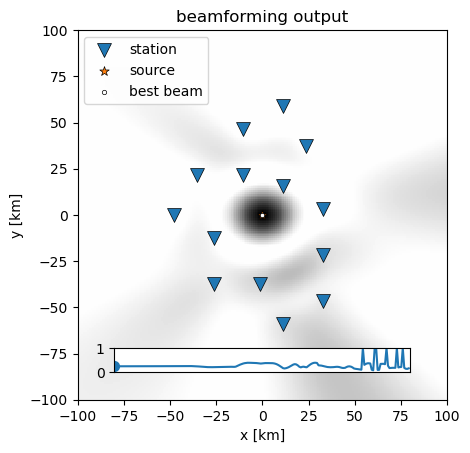

In [10]:
# plot beamforming result
from cmcrameri import cm
fig, ax = plt.subplots(1)

bp_all = beampowers.reshape(len(sources), len(grid_coords), len(grid_coords))
# normalise each bp in bp_all using pytorch

bp = bp_all[0]
bp /= abs(bp).max()
# pcm = ax.pcolorfast(grid_coords, grid_coords, bp.T, cmap="PuOr", vmin=-1, vmax=1)
pcm = ax.pcolorfast(grid_coords, grid_coords, bp.T, cmap=cm.grayC, vmin=0, vmax=1)
ax.scatter(*stations.T, marker="v", s=100, label="station", ec='k', lw=0.5)
sct_source = ax.scatter(*source, marker="*", s=50, label="source", ec='k', lw=0.5)
sct = ax.scatter(
    *gridpoints[bp.argmax()],
    marker="o",
    ec="k",
    lw=0.5,
    c="w",
    s=10,
    label="best beam",
)
# ax.pcolormesh(xx, yy, empty_cells, ec="k", lw=0.1, alpha=0.5)
# plt.colorbar(pcm, label="normalised beampower")
ax.set_xlim(-100, 100)
ax.set_ylim(-100, 100)
ax.set_aspect("equal")
ax.legend(loc=2)
ax.set_xlabel("x [km]")
ax.set_ylabel("y [km]")
ax.set_title("beamforming output")


# # add ax at bottom of current ax
x0, y0, w, h = ax.get_position().bounds
ax2 = fig.add_axes([x0 + 0.1 * w, y0+0.1*w, 0.8 * w, 0.05])
ax2.plot(second_peak_amplitudes)
ax2.set_xlim(0, len(second_peak_amplitudes))
ax2.set_xticks([])
ax2.set_ylim(0, 1)
# marker for current source
sct_peak = ax2.scatter(0, second_peak_amplitudes[0], marker="o", c="tab:blue", s=50)

# animate for all beampowers
from matplotlib.animation import FuncAnimation

def animate(i):
    bp_now = bp_all[i]
    bp_now /= abs(bp_now).max()

    peak = gridpoints[bp_now.argmax()]
    pcm.set_array(bp_now.T)
    sct.set_offsets(peak)
    sct_source.set_offsets(sources[i])

    sct_peak.set_offsets([i, second_peak_amplitudes[i]])

    return pcm

anim = FuncAnimation(fig, animate, frames=len(sources), interval=100)
anim.save("monotile_beamforming.mp4", dpi=300)
# anim.save("circle_beamforming.mp4", dpi=300)

